In [2]:
# CELL 1: Load Data + Initial Cleaning
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import boxcox
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load dataset
try:
    df = pd.read_csv("../data/diamonds.csv")
except FileNotFoundError:
    raise FileNotFoundError("❌ diamonds.csv not found. Please fix the path.")

print("Original Shape:", df.shape)

# Drop unnecessary index column
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# Replace invalid zero dimensions with NaN
df[['x','y','z']] = df[['x','y','z']].replace(0, np.nan)

# Drop rows where x,y,z invalid
df.dropna(inplace=True)

print("Shape After Removing Invalid Dimensions:", df.shape)
df.head()


Original Shape: (53940, 10)
Shape After Removing Invalid Dimensions: (53920, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
# CELL 2: Feature Engineering + Outlier Removal

INR_CONVERSION_RATE = 85

# Feature Engineering Requirements
df["price_inr"] = df["price"] * INR_CONVERSION_RATE
df["volume"] = df["x"] * df["y"] * df["z"]
df["price_per_carat"] = df["price"] / df["carat"]
df["dimension_ratio"] = (df["x"] + df["y"]) / (2 * df["z"])

# Corrected Carat Category (Light <0.5, Medium 0.5–1.5, Heavy >1.5)
bins = [0, 0.5, 1.5, df["carat"].max()]
labels = ["Light", "Medium", "Heavy"]
df["Carat_Category"] = pd.cut(df["carat"], bins=bins, labels=labels, right=False)

print("Feature Engineering Completed.")

# -------- IMPROVED OUTLIER REMOVAL (IQR APPLIED ONCE) -------- #
def remove_outliers_iqr(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean

features_to_check = ['carat','depth','table','x','y','z','price_inr']

before = df.shape[0]
df = remove_outliers_iqr(df, features_to_check)
after = df.shape[0]

print(f"Outlier Removal — Rows Before: {before}, After: {after}, Removed: {before-after}")


Feature Engineering Completed.
Outlier Removal — Rows Before: 53920, After: 46530, Removed: 7390


Skewness Before:
carat        0.685814
price_inr    1.143360
volume       0.685390
dtype: float64

Skewness After:
carat        0.402033
price_inr    0.063818
volume       0.057879
dtype: float64


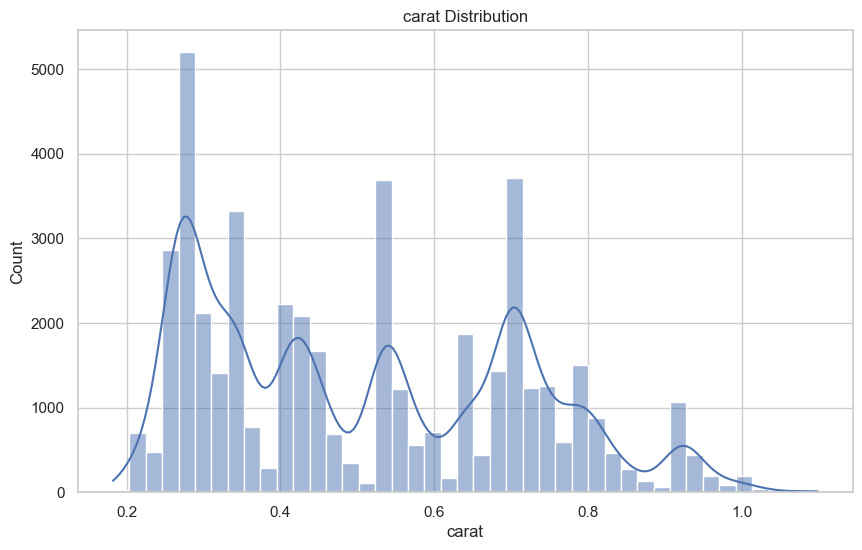

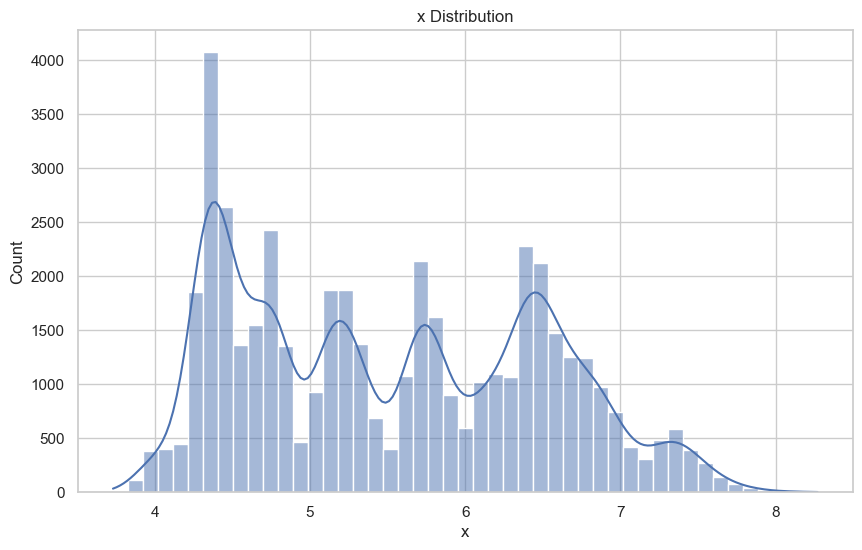

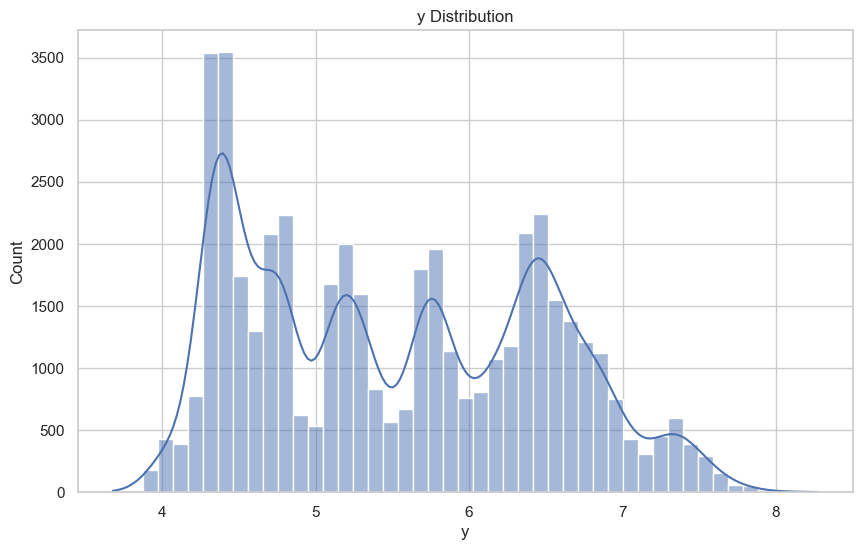

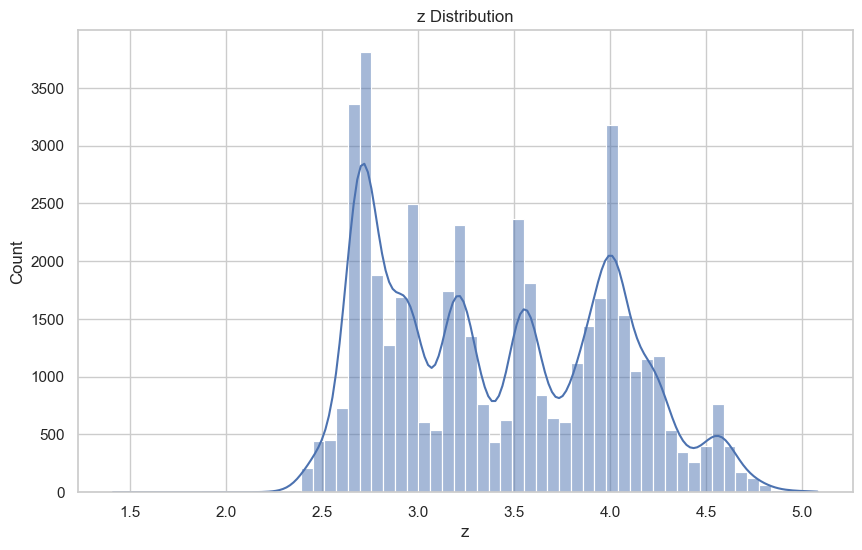

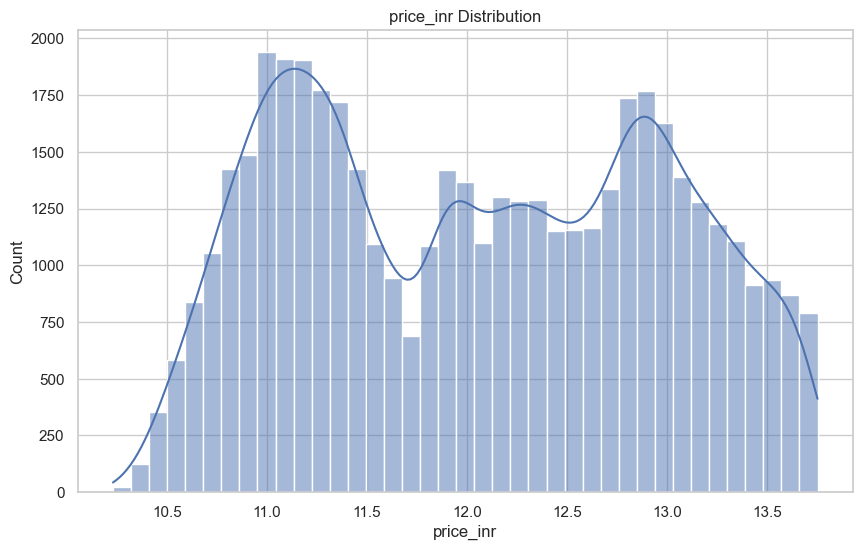

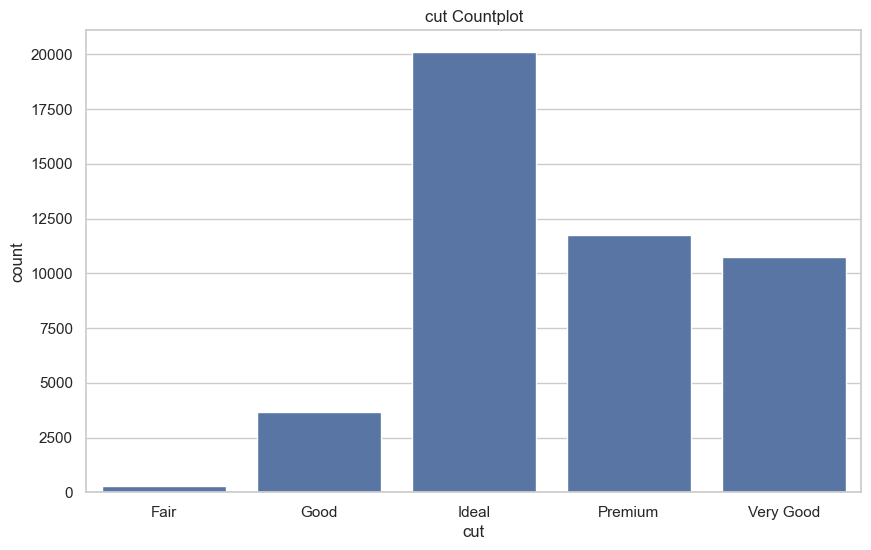

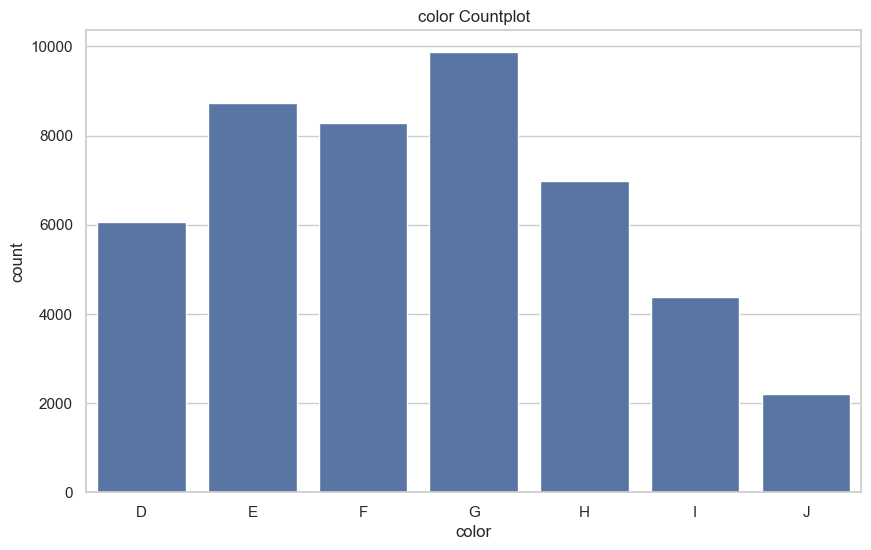

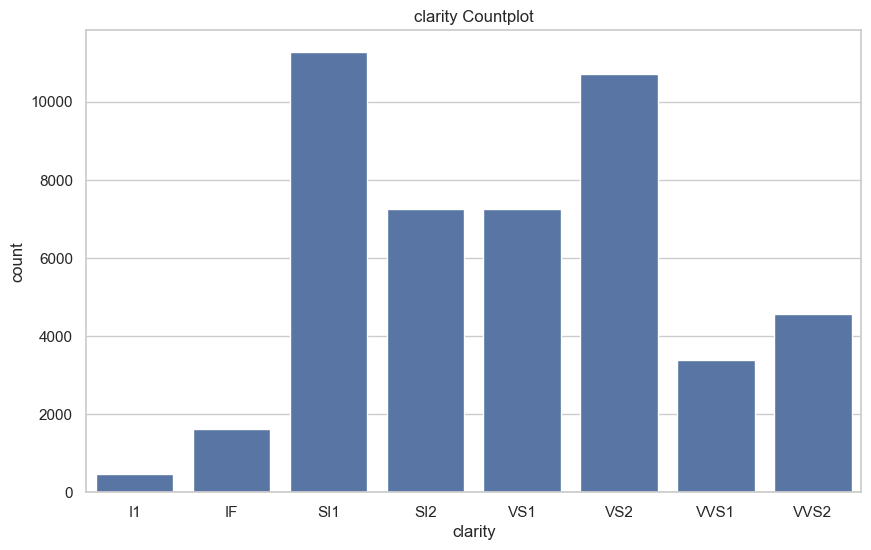

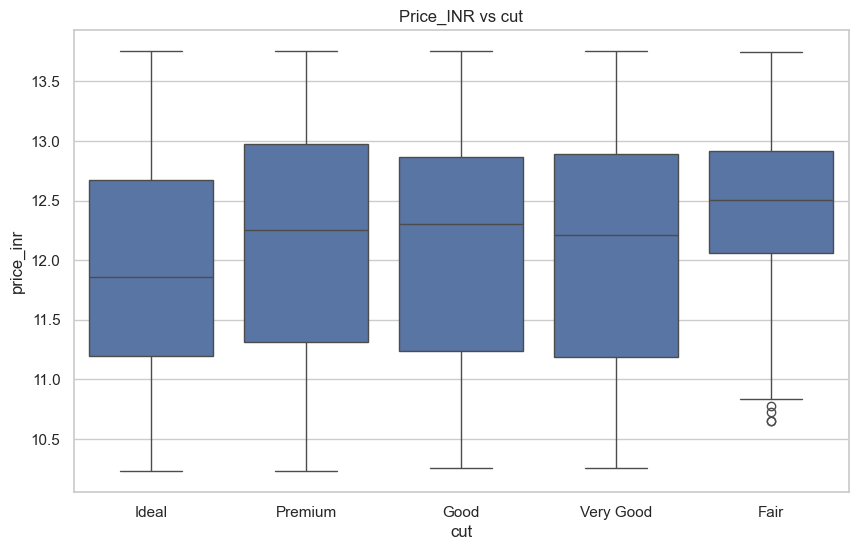

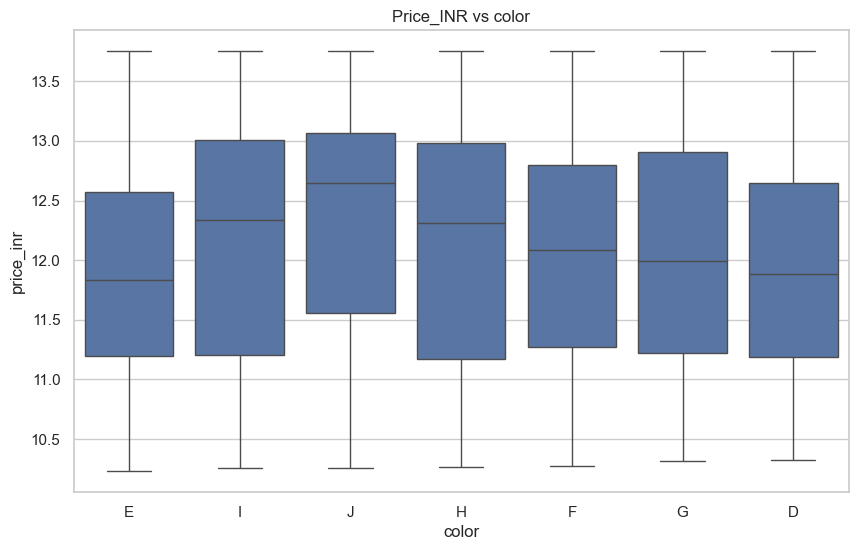

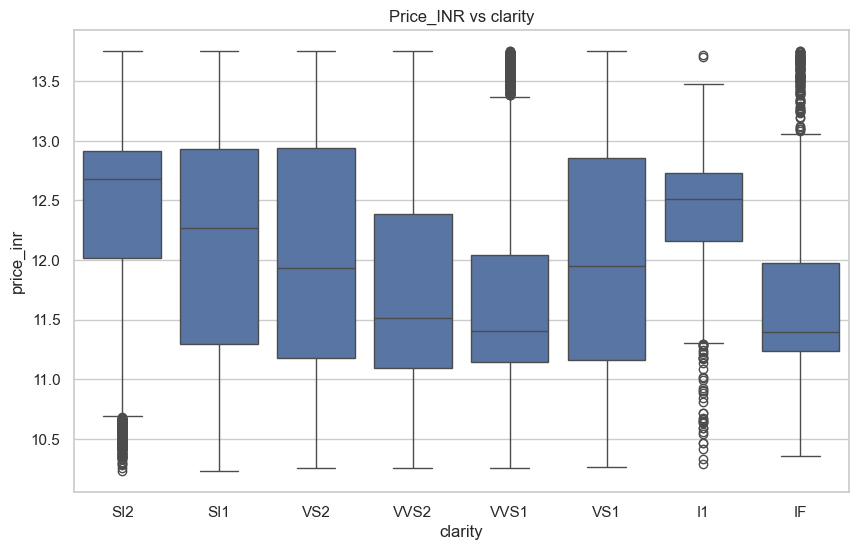

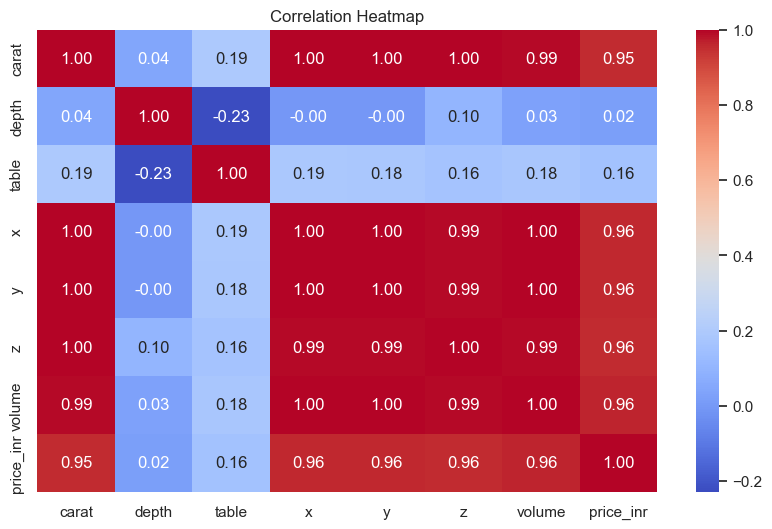

In [4]:
# CELL 3: Skewness Handling + EDA Visualizations

skewed_features = ["carat", "price_inr", "volume"]

print("Skewness Before:")
print(df[skewed_features].skew())

# Apply log1p transformation
for col in skewed_features:
    df[col + '_log'] = np.log1p(df[col])

# Replace original columns
df.drop(columns=skewed_features, inplace=True)
df.rename(columns={f"{col}_log": col for col in skewed_features}, inplace=True)

print("\nSkewness After:")
print(df[skewed_features].skew())

# ---------- EDA VISUALS ---------- #
# 1. Distribution
for col in ['carat','x','y','z','price_inr']:
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

# 2. Categorical Countplots
for col in ["cut","color","clarity"]:
    sns.countplot(data=df, x=col, order=sorted(df[col].unique()))
    plt.title(f"{col} Countplot")
    plt.show()

# 3. Price vs categorical
for col in ["cut","color","clarity"]:
    sns.boxplot(x=col, y="price_inr", data=df)
    plt.title(f"Price_INR vs {col}")
    plt.show()

# 4. Correlation Heatmap
numerical_cols = ["carat","depth","table","x","y","z","volume","price_inr"]
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [5]:
# CELL 4: Feature Selection (VIF) + Save Clean Data

numerical_features = ["carat","depth","table","x","y","z","volume"]

# Scale for VIF
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numerical_features])

vif_data = pd.DataFrame()
vif_data["Feature"] = numerical_features
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(len(numerical_features))]

print("VIF Scores:")
print(vif_data.sort_values(by="VIF", ascending=False))

# Drop one highly collinear variable if >10
highest_vif = vif_data.sort_values(by="VIF", ascending=False).iloc[0]
if highest_vif["VIF"] > 10:
    df.drop(columns=[highest_vif["Feature"]], inplace=True)
    print(f"\nDropped High-VIF Feature: {highest_vif['Feature']}")

# Remove original USD price
if "price" in df.columns:
    df.drop(columns=["price"], inplace=True)

# Save processed dataset
df.to_csv("../data/processed_diamonds.csv", index=False)

print("\n✔ Processing Complete — File Saved as processed_diamonds.csv")
print("Final Shape:", df.shape)
df.head()


VIF Scores:
  Feature          VIF
3       x  1071.331035
0   carat  1005.230126
4       y   821.387079
6  volume   812.031678
5       z   732.182758
1   depth     7.653102
2   table     1.409808

Dropped High-VIF Feature: x

✔ Processing Complete — File Saved as processed_diamonds.csv
Final Shape: (46530, 13)


,cut,color,clarity,depth,table,y,z,price_per_carat,dimension_ratio,Carat_Category,carat,price_inr,volume
0,Ideal,E,SI2,61.5,55.0,3.98,2.43,1417.391304,1.631687,Light,0.207014,10.229585,3.668729
1,Premium,E,SI1,59.8,61.0,3.84,2.31,1552.380952,1.673160,Light,0.190620,10.229585,3.569698
3,Premium,I,VS2,62.4,58.0,4.23,2.63,1151.724138,1.602662,Light,0.254642,10.253827,3.865447
4,Good,J,SI2,63.3,58.0,4.35,2.75,1080.645161,1.580000,Light,0.270027,10.256817,3.968729
5,Very Good,J,VVS2,62.8,57.0,3.96,2.48,1400.000000,1.592742,Light,0.215111,10.259797,3.681199
